In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd

hpd.util.get_color_logger("INFO")

<RootLogger root (INFO)>

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

**Het extent is in Rijksdriehoek (xmin, xmax, ymin, ymax). Meetpunten binnen dit extent worden ingeladen.**

**Met which-timeseries kun je de bron van de grondwatermetingen selecteren:** 
- Hand is handmatig gemeten door een persoon
- Diver is gemeten met een sensor
- Diver_validated is gemeten met een sensor en gevalideerd door de databeheerder

In [3]:
my_extent = (89945, 91552, 440688, 441553) 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 10
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  2.84it/s]


In [4]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs
name,,,,,,,,,,,,,
GMW000000036741001,90998.687871,441239.318459,MEIJPL-12,,lizard,m NAP,1,-15.680,-16.680,-4.560,-2.680,True,GroundwaterObs GMW000000036741001 -----metadat...
GMW000000036965001,91525.037726,441090.628347,128572-792,,lizard,m NAP,1,-5.970,-6.970,-4.850,-4.970,True,GroundwaterObs GMW000000036965001 -----metadat...
GMW000000036989001,90664.868686,441145.728338,127572-1,,lizard,m NAP,1,-5.150,-7.150,-4.340,-4.350,True,GroundwaterObs GMW000000036989001 -----metadat...
GMW000000037445001,90407.518334,440789.329306,127571-4,,lizard,m NAP,1,-5.390,-7.390,-4.830,-4.890,True,GroundwaterObs GMW000000037445001 -----metadat...
GMW000000038220001,91303.067938,441217.968233,128572-795,,lizard,m NAP,1,-16.560,-18.560,-4.680,-3.560,True,GroundwaterObs GMW000000038220001 -----metadat...
GMW000000098093001,91547.087277,441459.765282,128572-798,,lizard,m NAP,1,-6.807,-7.807,-4.807,-4.884,True,GroundwaterObs GMW000000098093001 -----metadat...
GMW000000101405001,91513.987745,441096.026782,128572-9,,lizard,m NAP,1,-6.410,-7.410,-4.860,-4.860,True,GroundwaterObs GMW000000101405001 -----metadat...
GMW000000101406001,91466.987589,441235.026233,128572-12,,lizard,m NAP,1,-6.390,-7.390,-4.840,-4.840,True,GroundwaterObs GMW000000101406001 -----metadat...
GMW000000101454001,91522.988168,440812.027927,128571-3,,lizard,m NAP,1,-6.390,-7.390,-4.740,-4.740,True,GroundwaterObs GMW000000101454001 -----metadat...


**In deze stap wordt één specifieke peilbuis geselecteerd uit de ObsCollection op basis van de unieke well code.**

In [5]:
gw = oc.obs["GMW000000036965001"]
print(gw)

GroundwaterObs GMW000000036965001
-----metadata------
name : GMW000000036965001 
x : 91525.03772620695 
y : 441090.6283468774 
location : 128572-792 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -5.97 
screen_bottom : -6.97 
ground_level : -4.85 
tube_top : -4.97 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2011-11-15 00:00:00  -5.96   NaN  Gemeten   hand
2012-01-17 14:58:00  -5.87   NaN  Gemeten   hand
2012-03-12 10:02:00  -5.89   NaN  Gemeten   hand
2012-05-09 23:00:00  -5.76   NaN  Gemeten   hand
2012-07-13 19:59:00  -5.83   NaN  Gemeten   hand
...                    ...   ...      ...    ...
2025-12-14 09:25:19  -5.70   2.0           diver
2025-12-14 13:25:21  -5.71   2.0           diver
2025-12-14 17:25:23  -5.71   2.0           diver
2025-12-14 21:25:24  -5.70   2.0           diver
2025-12-15 01:25:26  -5.71   2.0           diver

[7767 rows x 4 column

**In deze stap wordt de grondwaterstandtijdreeks uit de geselecteerde peilbuis geëxtraheerd en opgeschoond:**

- De kolom "value" (grondwaterstand) wordt gekopieerd uit het "GroundwaterObs" object  
- De datums worden omgezet naar pandas datetimes zodat tijdreeks bewerkingen mogelijk zijn  
- Ontbrekende metingen (NaN-waarden) worden verwijderd

**Tot slot wordt gecontroleerd:**
- Wat de eerste en laatste meetdatum zijn  
- Hoeveel metingen de tijdreeks bevat  

In [6]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)

2011-11-15 00:00:00 2025-12-15 01:25:26
(7763,)


**In deze stap wordt de tijdreeks beperkt tot de gekozen analyseperiode. Vervolgens wordt in het geval van meerdere metingen per dag een gemiddelde genomen zodat de tijdreeks maximaal 1 waarde per dag bevat en geschikt is om te plotten.**

In [7]:
ts_year = ts.loc["2024-11-01":"2025-10-31"]

# Dagelijkse reeks
ts_daily_raw = ts_year.resample("D").mean()

# Interpolatie (volledig automatisch)
ts_daily = ts_daily_raw.interpolate(method="time")

# Bijhouden welke dagen GEÏNTERPOLEERD zijn
is_interpolated = ts_daily_raw.isna()

**In deze stap wordt een vaste droogtedrempel bepaald op basis van een percentiel van de volledige grondwaterstandtijdreeks.**

**Het 30e percentiel betekent dat 30% van alle gemeten grondwaterstanden lager ligt dan deze waarde. Deze drempel wordt gebruikt om droogte te identificeren: wanneer de grondwaterstand onder deze waarde komt, wordt dit als een droogteconditie beschouwd.**

In [8]:
# Percentiel instellen
percentile = 0.30
threshold = ts_year.quantile(percentile)

# Bouw percentiel-uitleg tabel op RUWE DATA
df_pct = (
    ts_year          # ← NU gefilterd
    .sort_values()
    .to_frame(name="value")
    .reset_index(names="date")
)


df_pct["rank"] = range(1, len(df_pct) + 1)
df_pct["cum_frac"] = df_pct["rank"] / len(df_pct)
df_pct["below_threshold"] = df_pct["value"] <= threshold
df_pct["is_percentile_boundary"] = (
    (df_pct["cum_frac"] >= percentile) &
    (df_pct["cum_frac"].shift(1) < percentile)
)

print(f"Fixed threshold (30th percentile): {threshold:.2f} m NAP")

df_pct

Fixed threshold (30th percentile): -5.75 m NAP


,date,value,rank,cum_frac,below_threshold,is_percentile_boundary
0,2025-10-01 13:13:25,-5.880,1,0.000336,True,False
1,2025-09-09 17:09:57,-5.880,2,0.000671,True,False
2,2025-09-06 01:09:22,-5.870,3,0.001007,True,False
3,2025-09-09 05:09:52,-5.870,4,0.001343,True,False
4,2025-09-09 01:09:51,-5.870,5,0.001678,True,False
...,...,...,...,...,...,...
2974,2025-01-06 09:00:00,-5.416,2975,0.998657,False,False
2975,2025-01-06 05:00:00,-5.406,2976,0.998993,False,False
2976,2025-01-05 17:00:00,-5.405,2977,0.999329,False,False
2977,2025-01-06 01:00:00,-5.395,2978,0.999664,False,False


In [9]:
is_drought = ts_daily < threshold

**In deze stap wordt per dag bepaald of er sprake is van eengrondwaterdroogte.**

**Een dag wordt als droogtedag geclassificeerd wanneer de dagelijkse
grondwaterstand lager is dan de vastgestelde droogtedrempel.**

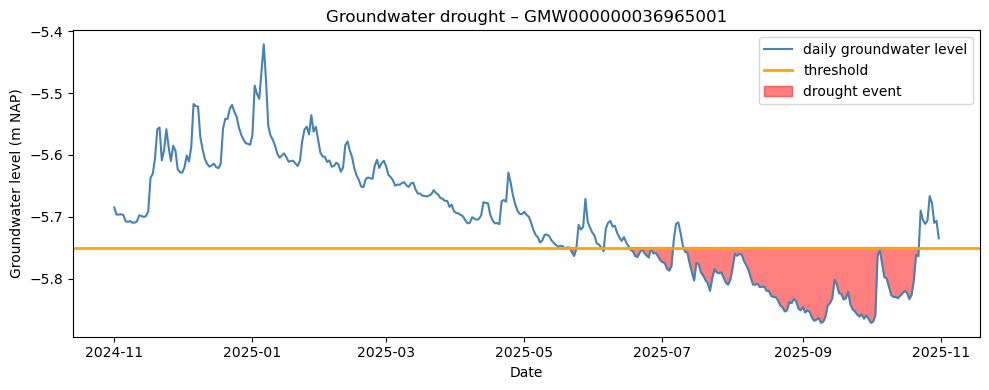

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

# Groundwater level
ax.plot(
    ts_daily.index,
    ts_daily,
    color="steelblue",
    linewidth=1.5,
    label="daily groundwater level",
)

# Fixed threshold
ax.axhline(threshold, color="orange", linewidth=2, label="threshold")

ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold,
    where=is_drought,
    color="red",
    alpha=0.5,
    label="drought event",
    interpolate=True,
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – {gw.name}")
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
duration_days = is_drought.sum()
max_deficit = (threshold - ts_daily[is_drought]).max()

n_interpolated = is_interpolated.sum()

print(
    f"Drought duration (2024–2025): {duration_days} days. "
    f"{n_interpolated} days were interpolated."
)
print(f"Maximum deficit (2024–2025): {max_deficit:.2f} m")

Drought duration (2024–2025): 130 days. 2 days were interpolated.
Maximum deficit (2024–2025): 0.12 m


In [12]:
# Origin per dag
origin_per_day = (
    gw[["value", "origin"]]
    .dropna()
    .assign(date=lambda df: df.index.normalize())
    .groupby("date")["origin"]
    .agg(lambda x: ",".join(sorted(set(x))))
)

summary = pd.DataFrame({
    "value": ts_daily,
    "interpolated": is_interpolated
})

summary["origin"] = origin_per_day
summary.loc[summary["interpolated"], "origin"] = "interpolated"

pd.set_option("display.max_rows", None)
summary

,value,interpolated,origin
peil_datum_tijd,,,
2024-11-01,-5.685000,False,diver_validated
2024-11-02,-5.696500,False,diver_validated
2024-11-03,-5.696500,False,diver_validated
2024-11-04,-5.696167,False,diver_validated
2024-11-05,-5.697167,False,diver_validated
2024-11-06,-5.707167,False,diver_validated
2024-11-07,-5.708500,False,diver_validated
2024-11-08,-5.707000,False,diver_validated
2024-11-09,-5.709667,False,diver_validated
